Why the hypothesis family? 

This is a *limiting* factor, which seems to stop one to achieve better accuracy / performance. However, this limitation is crucial in machine learning. It is this limit that introduces necessary "inductive biases". The "biases" allow the model to generalize beyond the training data. 

We will see an example, where without imposing any restrictions except toto adhere to the training data (perfect match!) 

We will see that this lacks the ability to predict on unseen instances. 

Lack of prior limitations leads to overfit to the data.

In [59]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X, y = X[:100, :2], (y[:100]-0.5)*2

# Center and normalize each feature to [-1,1]
X = X - np.mean(X, axis=0)
X = X / np.max(np.abs(X), axis=0)

grid_num = 50
xgrid, ygrid = np.meshgrid(np.linspace(-1, 1, grid_num), np.linspace(-1, 1, grid_num))
gridsamples = np.stack([xgrid.flatten(), ygrid.flatten()]).T

def fit_train(gridsamples, X, y, d=0.023):
    constraints = {}

    for i, xi in enumerate(X):
        dist = np.linalg.norm(gridsamples - xi, axis=1)
        idxs = np.where(dist < d)[0]
        for idx in idxs:
            constraints[idx] = [gridsamples[idx, 0], gridsamples[idx, 1], y[i]]
    return constraints

def get_h(gridsamples, constraints, rng=None):
    if rng is None:
        rng = np.random.RandomState(42)
    gridlabels = []
    for i in range(len(gridsamples)):
        if i in constraints:
            gridlabels.append(constraints[i][-1])
        else:
            gridlabels.append(rng.choice([-1, 1]))
    return gridlabels

rng = np.random.RandomState(42)
constraints = fit_train(gridsamples, X, y)

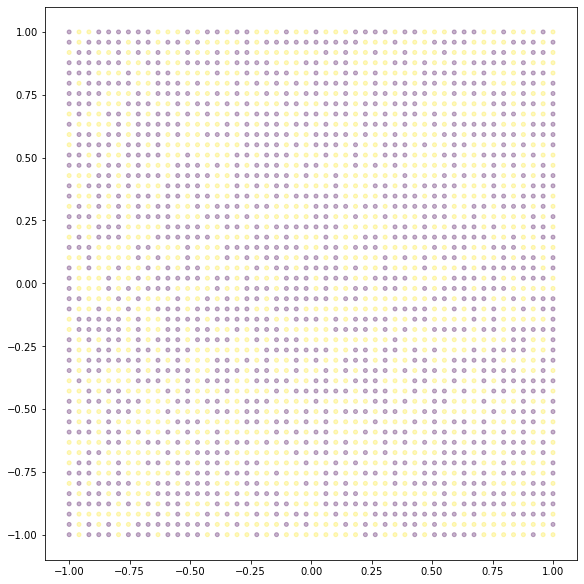

In [54]:
import matplotlib.pyplot as plt

fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8,8))
# ax2.scatter(X[:, 0], X[:, 1], c=y, s=100, marker='s', alpha=0.5)

constraints = {}
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

In [48]:
# How may possiblilies?
n0 = 2 ** len(gridsamples)
print(n0)

375828023454801203683362418972386504867736551759258677056523839782231681498337708535732725752658844333702457749526057760309227891351617765651907310968780236464694043316236562146724416478591131832593729111221580180531749232777515579969899075142213969117994877343802049421624954402214529390781647563339535024772584901607666862982567918622849636160208877365834950163790188523026247440507390382032188892386109905869706753143243921198482212075444022433366554786856559389689585638126582377224037721702239991441466026185752651502936472280911018500320375496336749951569521541850441747925844066295279671872605285792552660130702047998218334749356321677469529682551765858267502715894007887727250070780350262952377214028842297486263597879792176338220932619489509376


Fit 101 gridsamples


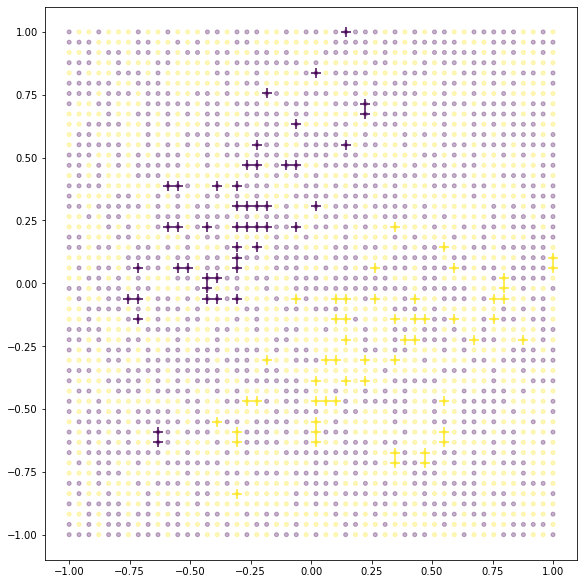

In [83]:
fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8, 8))
constraints = fit_train(gridsamples, X, y, d=0.025)
print(f"Fit {len(constraints)} gridsamples")
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

In [68]:
n1 = 2**(len(gridsamples) - len(constraints))


print(f"The possible solutions is now 1/{2**len(constraints)}")

print(f"Now there are only \n", n1, "\npossibilities")

The possible solutions is now 1/23489251465925075230210151185774156554233534484953667316032739986389480093646106783483295359541177770856403609345378610019326743209476110353244206935548764779043377707264785134170276029911945739537108069451348761283234327048594723748118692196388373069874679833987628088851559650138408086923852972708720939048286556350479178936410494913928102260013054835364684385236886782689140465031711898877011805774131869116856672071452745074905138254715251402085409674178534961855599102382911398576502357606389999465091626636609540718933529517556938656270023468521046871973095096365652609245365254143454979492037830362034541258168877999888645921834770104841845605159485366141718919743375492982953129423771891434523575876802643592891474867487011021138808288718094336
Now there are only 
 16 
possibilities
